In [30]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
(x_train,y_train),(x_test,y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2014s 12us/step


In [3]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [5]:
x_train.shape

(50000, 32, 32, 3)

In [6]:
x_test.shape

(10000, 32, 32, 3)

In [7]:
x_train = x_train/255.0
x_test = x_test/255.0
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

In [9]:
def plot_sample(x,y,index):
    plt.figure(figsize = (15,2))
    plt.imshow(x[index])
    plt.title(classes[y[index]])

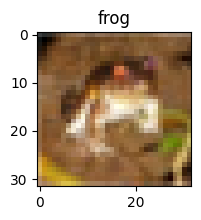

In [10]:
plot_sample(x_train,y_train,0)

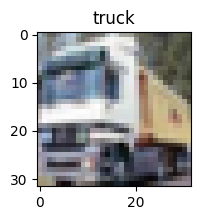

In [11]:
plot_sample(x_train,y_train,1)

In [22]:
cnn = models.Sequential([
    layers.Conv2D(filters = 32,kernel_size =(3,3),activation = 'relu',input_shape=(32,32,3)),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64,(3,3),activation = 'relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation = 'relu'),
    layers.Dense(32,activation = 'relu'),
    layers.Dense(16,activation = 'relu'),
    layers.Dense(10,activation = 'softmax')
])

cnn.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
cnn.fit(x_train,y_train,epochs = 10,batch_size = 32,validation_split = 0.2,callbacks = EarlyStopping())

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3866 - loss: 1.6580 - val_accuracy: 0.4947 - val_loss: 1.3998
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5447 - loss: 1.2661 - val_accuracy: 0.5832 - val_loss: 1.1778
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6161 - loss: 1.0867 - val_accuracy: 0.6259 - val_loss: 1.0874
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6522 - loss: 0.9858 - val_accuracy: 0.6450 - val_loss: 1.0121
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6836 - loss: 0.9021 - val_accuracy: 0.6465 - val_loss: 1.0101
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7072 - loss: 0.8347 - val_accuracy: 0.6673 - val_loss: 0.9751
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7277 - loss: 0.7792 - val_accuracy: 0.6759 - val_loss: 0.9555
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7445 - loss: 0.7306 - 

In [23]:
test_loss,test_accuracy = cnn.evaluate(x_test,y_test)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6725 - loss: 0.9846
Test Loss: 0.9845907092094421
Test Accuracy: 0.6725000143051147


In [24]:
predictions = cnn.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [27]:
predictions_classes = np.argmax(predictions,axis = 1)
print("Predicted:",predictions_classes[:10])
print("Actual:",y_test[:10])

Predicted: [3 8 8 0 6 6 1 2 3 1]
Actual: [3 8 8 0 6 6 1 6 3 1]


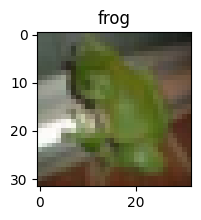

In [28]:
plot_sample(x_test,y_test,7)

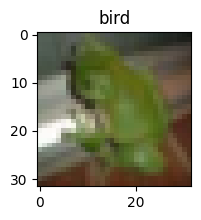

In [29]:
plot_sample(x_test,predictions_classes,7)#Wrong prediction

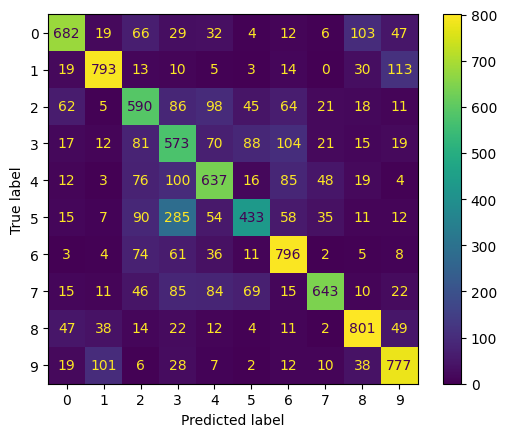

In [31]:
cm = confusion_matrix(y_test,predictions_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [32]:
print(classification_report(y_test,predictions_classes))

              precision    recall  f1-score   support

           0       0.77      0.68      0.72      1000
           1       0.80      0.79      0.80      1000
           2       0.56      0.59      0.57      1000
           3       0.45      0.57      0.50      1000
           4       0.62      0.64      0.63      1000
           5       0.64      0.43      0.52      1000
           6       0.68      0.80      0.73      1000
           7       0.82      0.64      0.72      1000
           8       0.76      0.80      0.78      1000
           9       0.73      0.78      0.75      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.67     10000
weighted avg       0.68      0.67      0.67     10000

